# 02 — Model Training

Bu notebook YOLOv8n modelini PASCAL VOC 2012-dən seçilmiş 4 klass (`bicycle`, `bus`, `car`, `motorbike`) üzərində
fine-tune edir. Model COCO dataset-i üzərində pre-trained `yolov8n.pt` weights-dən başlayır.

**Model seçimi əsaslandırması:** YOLOv8n seçildi çünki:
- CPU-da RT-DETR-dən ~2x daha sürətli training edir
- Kiçik obyektlər üçün güclüdür (urban mühitdə velosipedlər, motosikletlər)
- Inference sürəti ~5ms/şəkil — real-time avtonom sistem üçün uyğundur
- RT-DETR-in üstünlüyü: izdihamlı səhnələrdə kontekst anlayışı — amma bu üstünlük
  daha böyük dataset və GPU tələb edir, CPU-da praktiki deyil

## 1. İmportlar və Seed

In [1]:
import random
import time
from pathlib import Path

import numpy as np
import torch
from ultralytics import YOLO

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Ultralytics yükləndi.')
print(f'PyTorch versiyası : {torch.__version__}')
print(f'CUDA mövcuddur    : {torch.cuda.is_available()}')
print(f'Device            : {"cuda" if torch.cuda.is_available() else "cpu"}')

Ultralytics yükləndi.
PyTorch versiyası : 2.10.0+cpu
CUDA mövcuddur    : False
Device            : cpu


## 2. Konfiqurasiya

In [ ]:
# ── PATH KONFİQURASİYASI ──────────────────────────────────────────────────────
PROJECT_ROOT = Path(r'C:\Users\user\Desktop\project')
DATA_YAML    = PROJECT_ROOT / 'data.yaml'

# ── SABİT PARAMETRLƏR (dəyişdirilə bilməz) ───────────────────────────────────
MODEL_WEIGHTS = 'yolov8n.pt'   # COCO pretrained
IMGSZ         = 640            # input ölçüsü
EPOCHS        = 75             # 50-100 aralığı
BATCH         = 8              # CPU üçün kiçik batch
NC            = 4              # klass sayı

# ── SƏRBƏST PARAMETRLƏR ───────────────────────────────────────────────────────
# Learning rate: default 0.005 edildi - pretrained model üçün kiçik LR daha stabil fine-tuning verir
# yüksək LR fine-tuning-də weights-i poza bilər
LR0           = 0.005

# Early stopping: 25 epoch — kiçik dataset üçün kifayətdir
PATIENCE      = 25

# Optimizer: AdamW — adaptiv LR ilə daha stabil fine-tuning
OPTIMIZER     = 'AdamW'

# Augmentation: mosaic=1.0, flipud=0.0, fliplr=0.5 — urban mühit üçün
# hsv_h=0.015, hsv_s=0.7, hsv_v=0.4 — işıq dəyişkənliyi üçün
# scale=0.5 — müxtəlif məsafələrdəki obyektlər üçün

print(f'data.yaml : {DATA_YAML}')
print(f'Model     : {MODEL_WEIGHTS}')
print(f'Epochs    : {EPOCHS}')
print(f'Batch     : {BATCH}')
print(f'Optimizer : {OPTIMIZER}')
print(f'LR        : {LR0}')
print(f'Patience  : {PATIENCE}')

data.yaml : C:\Users\user\Desktop\project\data.yaml
Model     : yolov8n.pt
Epochs    : 75
Batch     : 8
Optimizer : AdamW
LR        : 0.005
Patience  : 25


## 3. Model Yüklə

In [3]:
model = YOLO(MODEL_WEIGHTS)
print(f'✅ {MODEL_WEIGHTS} yükləndi.')
print(f'Model parametr sayı: {sum(p.numel() for p in model.model.parameters()):,}')

✅ yolov8n.pt yükləndi.
Model parametr sayı: 3,157,200


## 4. Training

In [ ]:
print('Training başlayır...')

start_time = time.time()

results = model.train(
    # ── Sabit parametrlər ──
    data      = str(DATA_YAML),
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,
    seed      = SEED,
    # ── Sərbəst parametrlər ──
    lr0       = LR0,
    optimizer = OPTIMIZER,
    patience  = PATIENCE,
    # ── Augmentation ──
    mosaic    = 1.0,
    fliplr    = 0.5,
    flipud    = 0.0,
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    scale     = 0.5,
    # ── Layihə parametrləri ──
    project   = str(PROJECT_ROOT / 'runs'),
    name      = 'exp1',
    exist_ok  = True,
    device = 0 if torch.cuda.is_available() else 'cpu',
    workers   = 0,       # Windows-da multiprocessing xətasının qarşısını alır
)

elapsed = time.time() - start_time
hours   = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)

print(f'\n✅ Training tamamlandı!')
print(f'⏱️  Cəmi vaxt: {hours} saat {minutes} dəqiqə')
print(f'📁 Nəticələr: {PROJECT_ROOT}/runs/exp1/')

Training başlayır...
Ultralytics 8.4.21  Python-3.11.14 torch-2.10.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\user\Desktop\project\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW

## 5. Training Nəticələrini Göstər

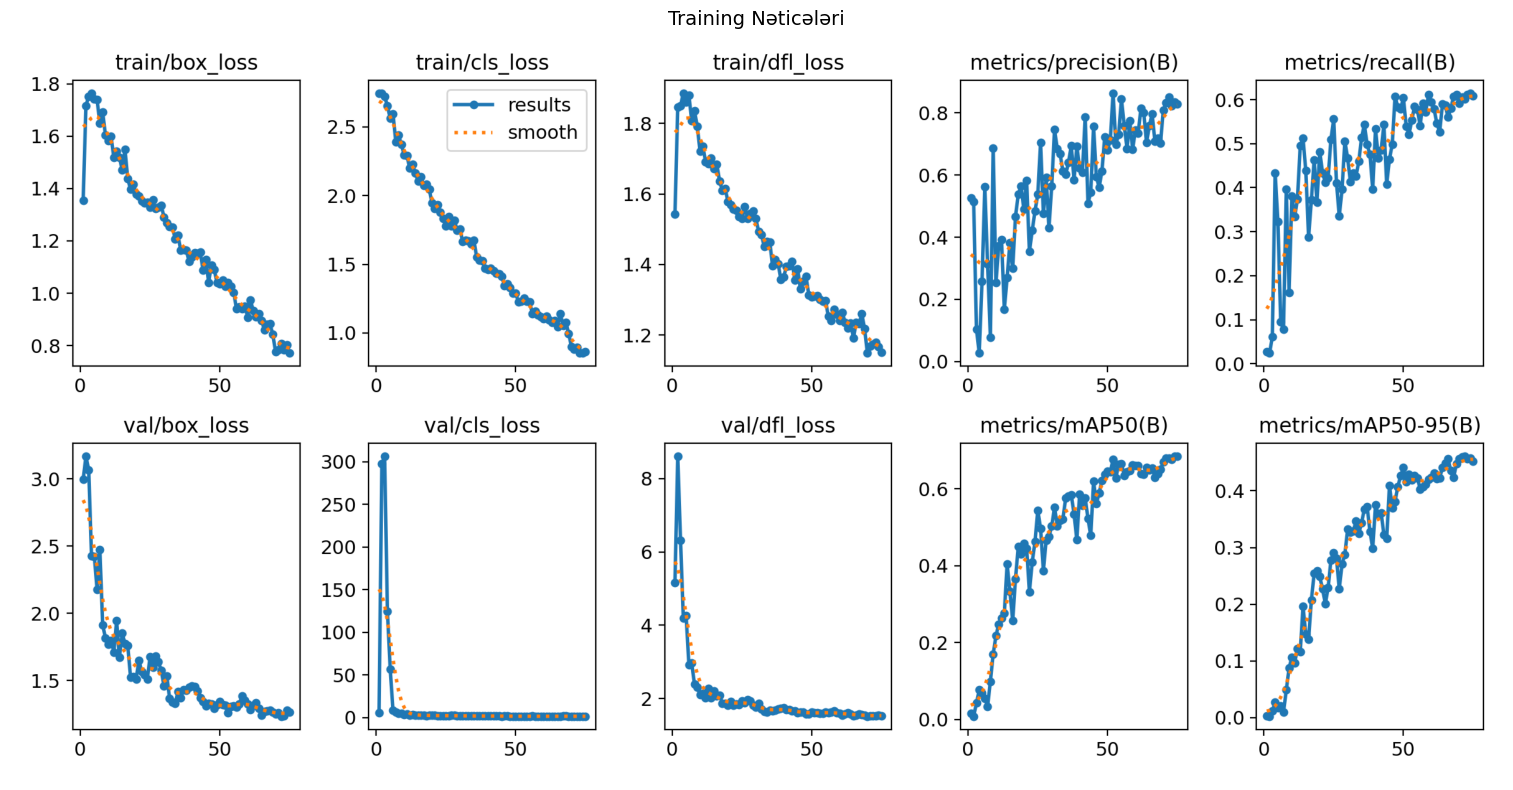

✅ Training loss curve göstərildi.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

PROJECT_ROOT = Path(r'C:\Users\user\Desktop\project') 
results_dir = PROJECT_ROOT / 'runs' / 'exp1'

# Training loss curve
results_png = results_dir / 'results.png'
if results_png.exists():
    img = mpimg.imread(results_png)
    plt.figure(figsize=(18, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training Nəticələri', fontsize=14)
    plt.tight_layout()
    plt.show()
    print('✅ Training loss curve göstərildi.')
else:
    print(f'results.png tapılmadı: {results_png}')

In [6]:
# Validation metrikları — training zamanı ən yaxşı epoch
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path(r'C:\Users\user\Desktop\project')
results_csv = PROJECT_ROOT / 'runs' / 'exp1' / 'results.csv'

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

# Ən yaxşı epoch — mAP50 maksimum olan sətir
best = df.loc[df['metrics/mAP50(B)'].idxmax()]

precision = best['metrics/precision(B)']
recall    = best['metrics/recall(B)']
f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print('📊 Ən yaxşı val metrikları (training zamanı):')
print(f'  Epoch        : {int(best["epoch"])}')
print(f'  mAP@0.5      : {best["metrics/mAP50(B)"]:.4f}')
print(f'  mAP@0.5:0.95 : {best["metrics/mAP50-95(B)"]:.4f}')
print(f'  Precision    : {precision:.4f}')
print(f'  Recall       : {recall:.4f}')
print(f'  F1-score     : {f1:.4f}')

📊 Ən yaxşı val metrikları (training zamanı):
  Epoch        : 74
  mAP@0.5      : 0.6845
  mAP@0.5:0.95 : 0.4571
  Precision    : 0.8337
  Recall       : 0.6149
  F1-score     : 0.7078
